In [ ]:
#代码示例：6-1
# [旧写法] from keras.preprocessing.image import ImageDataGenerator
# [新写法] 适用于 TensorFlow >= 2.0
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMSIZE=224

train_generator = ImageDataGenerator(rescale=1./255).flow_from_directory(
    '/course7/data/data_inception/train/',
    target_size=(IMSIZE, IMSIZE),
    batch_size=100,
    class_mode='categorical')

validation_generator = ImageDataGenerator(rescale=1./255).flow_from_directory(
    '/course7/data/data_inception/test/',
    target_size=(IMSIZE, IMSIZE),
    batch_size=100,
    class_mode='categorical')

<Figure size 432x288 with 0 Axes>

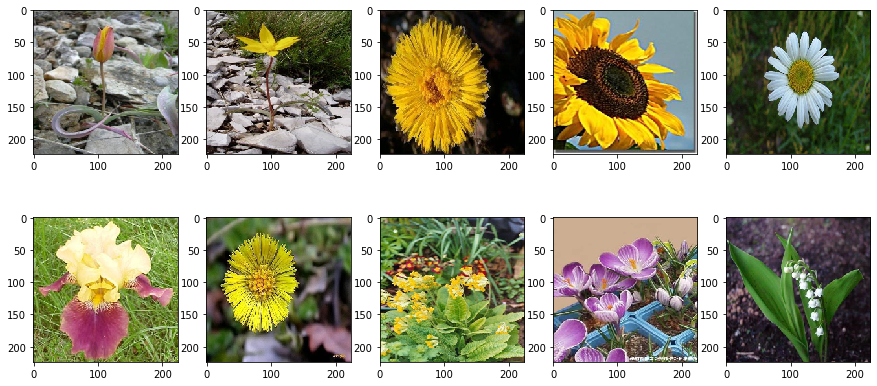

In [2]:
#代码示例：6-2
from matplotlib import pyplot as plt

plt.figure()
fig,ax = plt.subplots(2,5)
fig.set_figheight(7)
fig.set_figwidth(15)
ax=ax.flatten()
X,Y=next(train_generator)
for i in range(10): ax[i].imshow(X[i,:,:,:])

In [ ]:
#代码示例：6-3
# [旧写法] from keras.layers import Conv2D, BatchNormalization, MaxPooling2D
# [旧写法] from keras.layers import Flatten, Dropout, Dense, Input, concatenate
# [旧写法] from keras import Model
# [新写法] 适用于 TensorFlow >= 2.0
from tensorflow.keras.layers import Conv2D, BatchNormalization, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dropout, Dense, Input, concatenate
from tensorflow.keras import Model

#输入：224*224*3
input_layer = Input([IMSIZE,IMSIZE,3]) 
x = input_layer

#第一层:使用7x7的卷积核（滑动IMSIZE = 224,步长2，same padding），64通道；然后经过3x3的max pooling（步长为2）
x = Conv2D(64,(7,7),strides=(2,2),padding='same',activation='relu')(x) #para=(3*7*7+1)*64=9472
x = BatchNormalization(axis=3)(x) #para=4*64=256
x = MaxPooling2D(pool_size=(3,3),strides=(2,2),padding='same')(x) 

#第二层:使用3x3的卷积核（滑动步长为1，same padding），192通道；然后经过3x3的max pooling（步长为2）
x = Conv2D(192,(3,3),strides=(1,1),padding='same',activation='relu')(x) #para=(64*3*3+1)*192=110784
x = BatchNormalization(axis=3)(x) #para=4*192=768
x = MaxPooling2D(pool_size=(3,3),strides=(2,2),padding='same')(x) 

for i in range(9):
    #第三层:Inception 3a。后面的3b，4a-4e，5a，5b都用3a近似替代
    ##64个1x1的卷积核
    branch1x1 = Conv2D(64,(1,1),strides=(1,1),padding='same',activation='relu')(x) #para=(192*1*1+1)*64=12352
    branch1x1 = BatchNormalization(axis=3)(branch1x1) #para=4*64=256
    ##96个1x1的卷积核，再进行128个3x3的卷积
    branch3x3 = Conv2D(96,(1,1),strides=(1,1),padding='same',activation='relu')(x) #para=(192*1*1+1)*96=18528
    branch3x3 = BatchNormalization(axis=3)(branch3x3) #para=4*96=384
    branch3x3 = Conv2D(128,(3,3),strides=(1,1),padding='same',activation='relu')(branch3x3) #para=(96*3*3+1)*128=110720
    branch3x3 = BatchNormalization(axis=3)(branch3x3) #para=4*128=512
    ##16个1x1的卷积核，再进行32个5x5的卷积
    branch5x5 = Conv2D(16,(1,1),strides=(1,1),padding='same',activation='relu')(x) #para=(192*1*1+1)*16=3088
    branch5x5 = BatchNormalization(axis=3)(branch5x5) #para=4*16=64
    branch5x5 = Conv2D(32,(5,5),strides=(1,1),padding='same',activation='relu')(branch5x5) #para=(16*5*5+1)*32=12832
    branch5x5 = BatchNormalization(axis=3)(branch5x5) #para=4*32=128
    ##pool层，使用3x3的核，输出28x28x192，然后进行32个1x1的卷积
    branchpool = MaxPooling2D(pool_size=(3,3),strides=(1,1),padding='same')(x)
    branchpool = Conv2D(32,(1,1),strides=(1,1),padding='same',activation='relu')(branchpool) #para=(192*1*1+1)*32=6176
    branchpool = BatchNormalization(axis=3)(branchpool) #para=4*32=128
    x = concatenate([branch1x1,branch3x3,branch5x5,branchpool],axis=3)
    x = MaxPooling2D(pool_size=(3,3),strides=(2,2),padding='same')(x)


x = Dropout(0.4)(x)
x = Flatten()(x)
x = Dense(17,activation='softmax')(x)
output_layer=x
model=Model(input_layer,output_layer)
model.summary()

In [ ]:
#代码示例：6-4
# [旧写法] from keras.optimizers import Adam
# [新写法] 适用于 TensorFlow >= 2.0
from tensorflow.keras.optimizers import Adam
# [旧写法] model.compile(loss='categorical_crossentropy', optimizer=Adam(lr=0.001), metrics=['accuracy'])
# [新写法] 适用于 TensorFlow >= 2.11
model.compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])
# [旧写法] model.fit_generator(train_generator,epochs=10,validation_data=validation_generator)
# [新写法] 适用于 TensorFlow >= 2.1
model.fit(train_generator,epochs=10,validation_data=validation_generator)

In [ ]:
#代码示例：6-5
from matplotlib import pyplot as plt
# [旧写法] from keras.preprocessing.image import ImageDataGenerator
# [新写法] 适用于 TensorFlow >= 2.0
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMSIZE=224
train_generator = ImageDataGenerator(rescale=1./255).flow_from_directory(
    '/course7/data/data_res/train',
    target_size=(IMSIZE, IMSIZE),
    batch_size=100,
    class_mode='categorical')

validation_generator = ImageDataGenerator(rescale=1./255).flow_from_directory(
    '/course7/data/data_res/validation',
    target_size=(IMSIZE, IMSIZE),
    batch_size=100,
    class_mode='categorical')

plt.figure()
fig,ax = plt.subplots(2,5)
fig.set_figheight(7)
fig.set_figwidth(15)
ax=ax.flatten()

X,Y=next(train_generator)
for i in range(10): ax[i].imshow(X[i,:,:,:])

In [ ]:
#代码示例：6-6
# [旧写法] from keras.layers import Input
# [旧写法] from keras.layers import Activation, Conv2D, BatchNormalization, add, MaxPooling2D
# [新写法] 适用于 TensorFlow >= 2.0
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Activation, Conv2D, BatchNormalization, add, MaxPooling2D

NB_CLASS=3
IM_WIDTH=224
IM_HEIGHT=224

inpt = Input(shape=(IM_WIDTH, IM_HEIGHT, 3))

x = Conv2D(64, (7,7), padding='same', strides=(2,2), activation='relu')(inpt)
x = BatchNormalization()(x)
# 一个卷积层加一个batch normalization
x = MaxPooling2D(pool_size=(3, 3), strides=(2, 2), padding='same')(x)
x0 = x

In [3]:
#代码示例：6-7
# 一个block
x = Conv2D(64, (1,1), padding='same', strides=(1,1), activation='relu')(x)
x = BatchNormalization()(x)
# 一个卷积层加一个batch normalization
x = Conv2D(64, (3,3), padding='same', strides=(1,1), activation='relu')(x)
x = BatchNormalization()(x)
# 一个卷积层加一个batch normalization
x = Conv2D(256, (1,1), padding='same', strides=(1,1), activation=None)(x)
x = BatchNormalization()(x)
# 一个卷积层加一个batch normalization

# 下面两步为了把输入64通道的数据转换为256个通道，用来让x0和x维数相同，可以进行加法计算，文章中虚线得的部分
x0 = Conv2D(256,(1,1),padding='same',strides=(1,1),activation='relu')(x0)
x0 = BatchNormalization()(x0)
x = add([x,x0])# add把输入的x和经过一个block之后输出的结果加在一起
x = Activation('relu')(x)#求和之后的结果再做一次relu
x0 = x # 把输入存到一个另外的变量中

In [ ]:
#代码示例：6-8
# [旧写法] from keras.models import Model
# [新写法] 适用于 TensorFlow >= 2.0
from tensorflow.keras.models import Model
model = Model(inputs=inpt,outputs=x)
model.summary()

In [ ]:
#代码示例：6-9
#在resnet最后的部分添加一个dense层，并输出一个二维的结果用来分类
# [旧写法] from keras.layers import Dense, Flatten
# [新写法] 适用于 TensorFlow >= 2.0
from tensorflow.keras.layers import Dense, Flatten
x = model.output
x = Flatten()(x)
predictions = Dense(NB_CLASS,activation='softmax')(x)
model_res = Model(inputs=model.input,outputs=predictions)

In [ ]:
#代码示例：6-10
# [旧写法] from keras.optimizers import Adam
# [新写法] 适用于 TensorFlow >= 2.0
from tensorflow.keras.optimizers import Adam
# [旧写法] model_res.compile(loss='categorical_crossentropy',optimizer=Adam(lr=0.001),metrics=['accuracy'])
# [新写法] 适用于 TensorFlow >= 2.11
model_res.compile(loss='categorical_crossentropy',optimizer=Adam(learning_rate=0.001),metrics=['accuracy'])

# [旧写法] model_res.fit_generator(...)
# [新写法] 适用于 TensorFlow >= 2.1
model_res.fit(
    train_generator,
    steps_per_epoch=100,
    epochs=5,
    validation_data=validation_generator,
    validation_steps=100)

In [ ]:
#代码示例：6-11
# [旧写法] from keras.preprocessing.image import ImageDataGenerator
# [新写法] 适用于 TensorFlow >= 2.0
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMSIZE=128

validation_generator = ImageDataGenerator(rescale=1./255).flow_from_directory(
    '/course7/data/data_des/test',
    target_size=(IMSIZE, IMSIZE),
    batch_size=100,
    class_mode='categorical')
train_generator = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.5,
    rotation_range=30,
    zoom_range=0.2, 
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True).flow_from_directory(
    '/course7/data/data_des/train',
    target_size=(IMSIZE, IMSIZE),
    batch_size=100,
    class_mode='categorical')

<Figure size 432x288 with 0 Axes>

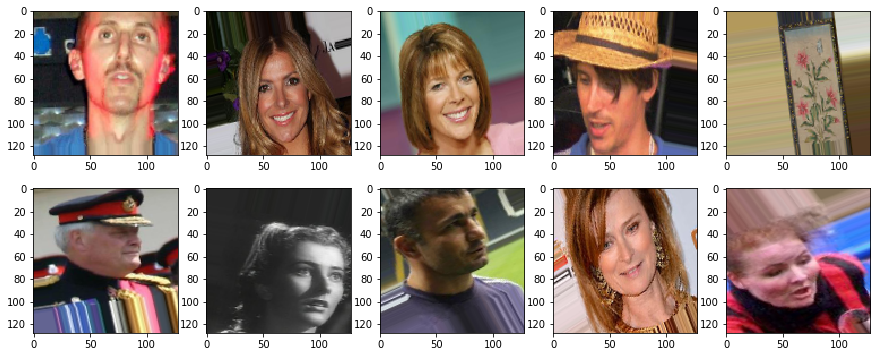

In [2]:
#代码示例：6-12
from matplotlib import pyplot as plt

plt.figure()
fig,ax = plt.subplots(2,5)
fig.set_figheight(6)
fig.set_figwidth(15)
ax=ax.flatten()
X,Y=next(train_generator)
for i in range(10): ax[i].imshow(X[i,:,:,:])

In [ ]:
#代码示例：6-13
# [旧写法] from keras.layers import Input,BatchNormalization,Conv2D,Dense,Flatten,Input,MaxPooling2D,Concatenate
# [旧写法] from keras.layers.pooling import AveragePooling2D,GlobalAveragePooling2D
# [旧写法] from keras import Model
# ↑ keras.layers.pooling 子模块在 TF 2.0+ 中已合并到 keras.layers
# [新写法] 适用于 TensorFlow >= 2.0
from tensorflow.keras.layers import Input,BatchNormalization,Conv2D,Dense,Flatten,MaxPooling2D,Concatenate
from tensorflow.keras.layers import AveragePooling2D,GlobalAveragePooling2D
from tensorflow.keras import Model

IMSIZE=128

# 每个dense block中dense layer数目 
nb_layers = 3
# 增长率
growth_rate = 32  

# 输入层
input_layer = Input([IMSIZE,IMSIZE,3])
x = input_layer

# 初始卷积层
x = BatchNormalization()(x)
x = Conv2D(growth_rate*2, (3,3), padding='same', activation='relu')(x)

In [4]:
#代码示例：6-14
# 设置 [Dense Block + Transition Block] 多个，此处以1个为例
for j in range(3):
    # 1.Dense Block
    # 用一个列表存放提供特征的层
    feature_list = [x]
    for i in range(nb_layers):   
        x = BatchNormalization()(x)
        x = Conv2D(growth_rate, (3, 3), padding="same", activation='relu')(x)   
        feature_list.append(x)
        if i<(nb_layers-1):
            x = Concatenate()(feature_list)
        
    
    # 2.Transition Block
    x = BatchNormalization()(x)
    x = Conv2D(growth_rate, (1, 1), padding="same", activation='relu')(x)
    x = AveragePooling2D((2, 2), strides=(2, 2))(x)

In [5]:
#代码示例：6-15
# 设置最后一个Dense Block （最后一个Dense Block不需要Transition Block）
feature_list = [x]
for i in range(nb_layers):            
    x = Conv2D(growth_rate, (3, 3), padding="same", activation='relu')(x)   
    feature_list.append(x)
    if i<(nb_layers-1):
        x = Concatenate()(feature_list)

# 全局池化
x = GlobalAveragePooling2D()(x)
x = Dense(2,activation='softmax')(x)
output_layer = x
model = Model(input_layer,output_layer)
model.summary()

Model: "model_1"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            (None, 128, 128, 3)  0                                            
__________________________________________________________________________________________________
batch_normalization_1 (BatchNor (None, 128, 128, 3)  12          input_1[0][0]                    
__________________________________________________________________________________________________
conv2d_1 (Conv2D)               (None, 128, 128, 64) 1792        batch_normalization_1[0][0]      
__________________________________________________________________________________________________
batch_normalization_2 (BatchNor (None, 128, 128, 64) 256         conv2d_1[0][0]                   
____________________________________________________________________________________________

In [ ]:
#代码示例：6-16
# [旧写法] from keras.optimizers import Adam
# [新写法] 适用于 TensorFlow >= 2.0
from tensorflow.keras.optimizers import Adam
# [旧写法] model.compile(loss='categorical_crossentropy',optimizer=Adam(lr=0.001),metrics=['accuracy'])
# [新写法] 适用于 TensorFlow >= 2.11
model.compile(loss='categorical_crossentropy',optimizer=Adam(learning_rate=0.001),metrics=['accuracy'])
# [旧写法] model.fit_generator(train_generator,epochs=5,validation_data=validation_generator)
# [新写法] 适用于 TensorFlow >= 2.1
model.fit(train_generator,epochs=5,validation_data=validation_generator)

In [ ]:
# 载入必要的库
import numpy as np
import tensorflow as tf
# [旧写法] import keras
# [新写法] 适用于 TensorFlow >= 2.0
from tensorflow import keras

from matplotlib import pyplot as plt

# [旧写法] from keras import Model
# [旧写法] from keras.optimizers import Adam
# [旧写法] from keras.preprocessing.image import ImageDataGenerator
# [旧写法] from keras.layers import Conv2D, BatchNormalization, MaxPooling2D, GlobalAveragePooling2D,AveragePooling2D
# [旧写法] from keras.layers import Flatten, Dropout, Dense, Input, Concatenate, add, Activation,ZeroPadding2D
# [旧写法] from keras.layers import ReLU, DepthwiseConv2D
# [新写法] 适用于 TensorFlow >= 2.0
from tensorflow.keras import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, BatchNormalization, MaxPooling2D, GlobalAveragePooling2D,AveragePooling2D
from tensorflow.keras.layers import Flatten, Dropout, Dense, Input, Concatenate, add, Activation,ZeroPadding2D
from tensorflow.keras.layers import ReLU, DepthwiseConv2D

In [ ]:
#代码示例：6-17
# [旧写法] from keras.preprocessing.image import ImageDataGenerator
# [新写法] 适用于 TensorFlow >= 2.0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import random
random.seed(2019425)

# Set image size
IMSIZE=112

# laod validation data
datagen = ImageDataGenerator(rescale=1. / 255,
                             shear_range=0.5,
                             rotation_range=30,
                             zoom_range=0.2,
                             width_shift_range=0.2,
                             height_shift_range=0.2,
                             horizontal_flip=True,
                             validation_split = 0.4)

validation_generator = datagen.flow_from_directory(
    '/course7/data/data_mob/',
    target_size=(IMSIZE, IMSIZE),
    batch_size=100,
    class_mode='categorical',
    subset = 'validation')

train_generator = datagen.flow_from_directory(
    '/course7/data/data_mob/',
    target_size=(IMSIZE, IMSIZE),
    batch_size=150,
    class_mode='categorical',
    subset = 'training')

plt.figure()
fig, ax = plt.subplots(2, 5)
fig.set_figheight(6)
fig.set_figwidth(15)
ax = ax.flatten()
X, Y = next(validation_generator)
for i in range(10):
    ax[i].imshow(X[i, :, :, ])
plt.show()

In [5]:
#代码示例：6-18
def _depthwise_conv_block(inputs, pointwise_conv_filters, alpha,
                           strides=(1, 1), block_id=1):

    """Adds a depthwise convolution block.

    A depthwise convolution block consists of a depthwise conv,
    batch normalization, relu6, pointwise convolution,
    batch normalization and relu6 activation.

    # Arguments

        inputs: Input tensor of shape `(rows, cols, channels)`

        pointwise_conv_filters: Integer, the dimensionality of the output space
            (i.e. the number of output filters in the pointwise convolution).

        alpha: controls the width of the network.

        strides: An integer or tuple/list of 2 integers,
            specifying the strides of the convolution
            along the width and height.

        block_id: Integer, a unique identification designating
            the block number.
            
    # Returns
        Output tensor of block.

    """

    pointwise_conv_filters = int(pointwise_conv_filters * alpha)

    if strides == (1, 1):
        x = inputs
    else:
        x = ZeroPadding2D(((0, 1), (0, 1)),
                          name='conv_pad_%d' % block_id)(inputs)

    x = DepthwiseConv2D((3, 3),
                               padding='same' if strides == (1, 1) else 'valid',
                               strides=strides,
                               use_bias=False,
                               name='conv_dw_%d' % block_id)(x)
    x = BatchNormalization(axis=-1, 
                                  name='conv_dw_%d_bn' % block_id)(x)
    x = ReLU(6., name='conv_dw_%d_relu' % block_id)(x)
    x = Conv2D(pointwise_conv_filters, (1, 1),
                      padding='same',
                      use_bias=False,
                      strides=(1, 1),
                      name='conv_pw_%d' % block_id)(x)
    x = BatchNormalization(axis=-1,
                                  name='conv_pw_%d_bn' % block_id)(x)
    
    return ReLU(6., name='conv_pw_%d_relu' % block_id)(x)

In [ ]:
#代码示例：6-19
# [旧写法] from keras.layers import ZeroPadding2D, ReLU, DepthwiseConv2D
# [新写法] 适用于 TensorFlow >= 2.0
from tensorflow.keras.layers import ZeroPadding2D, ReLU, DepthwiseConv2D
alpha = 1
depth_multiplier = 1

# 输入层
input_layer = Input([IMSIZE,IMSIZE,3]) 

# 初始卷积层
x = input_layer
x = ZeroPadding2D(padding = ((0,1),(0,1)),name='conv1_pad')(x)
x = Conv2D(32,(3,3),padding='valid',use_bias=False,strides=(2,2),name='conv1')(x)
x = BatchNormalization(axis=-1, name='conv1_bn')(x)
x = ReLU(6,name='conv1_relu')(x)

# 保留其中的一些深度可分离卷积层
x = _depthwise_conv_block(x, 64, alpha, block_id=1)
x = _depthwise_conv_block(x, 128, alpha, strides=(2, 2), block_id=2)
x = _depthwise_conv_block(x, 256, alpha, strides=(2, 2), block_id=3)
x = _depthwise_conv_block(x, 512, alpha, strides=(2, 2), block_id=4)
x = _depthwise_conv_block(x, 1024, alpha, strides=(2, 2), block_id=5)


# Average Pooling
x = GlobalAveragePooling2D()(x)

x = Dense(10,activation='softmax')(x)
model = Model(inputs=input_layer,outputs=x)
model.summary()

In [ ]:
#代码示例：6-20
model.compile(loss='categorical_crossentropy',
              # [旧写法] optimizer=Adam(lr=0.001),
              # [新写法] 适用于 TensorFlow >= 2.11
              optimizer=Adam(learning_rate=0.001),
              metrics=['accuracy'])

# [旧写法] model.fit_generator(...)
# [新写法] 适用于 TensorFlow >= 2.1
model.fit(
    train_generator,
    steps_per_epoch=100,
    epochs=5,
    validation_data=validation_generator,
    validation_steps=100)

In [ ]:
#代码示例：6-21
# [旧写法] from keras.applications.inception_v3 import preprocess_input
# [旧写法] from keras.preprocessing.image import ImageDataGenerator
# [新写法] 适用于 TensorFlow >= 2.0
from tensorflow.keras.applications.inception_v3 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMSIZE=224

validation_generator = ImageDataGenerator(
    preprocessing_function=preprocess_input).flow_from_directory(
    '/course7/data/CatDog/validation',
    target_size=(IMSIZE, IMSIZE),
    batch_size=100,
    class_mode='categorical')

In [2]:
#代码示例：6-22
train_generator = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    shear_range=0.5,
    rotation_range=30,
    zoom_range=0.2, 
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True).flow_from_directory(
    '/course7/data/CatDog/train',
    target_size=(IMSIZE, IMSIZE),
    batch_size=150,
    class_mode='categorical')

Found 15000 images belonging to 2 classes.


<Figure size 432x288 with 0 Axes>

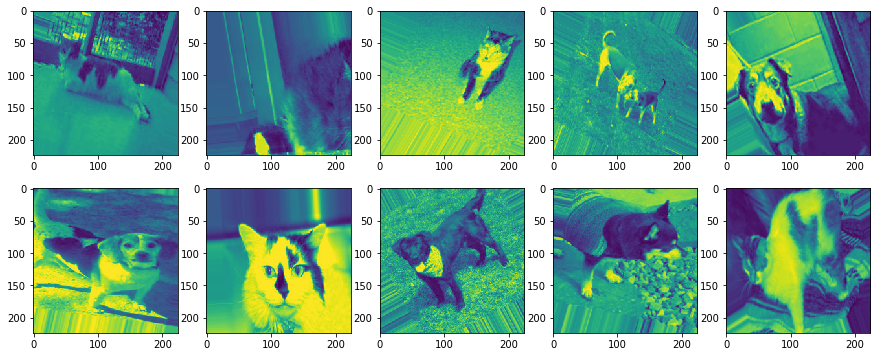

In [3]:
#代码示例：6-23
from matplotlib import pyplot as plt

plt.figure()
fig,ax = plt.subplots(2,5)
fig.set_figheight(6)
fig.set_figwidth(15)
ax=ax.flatten()
X,Y=next(train_generator)
for i in range(10): ax[i].imshow(X[i,:,:,0])

In [ ]:
#代码示例：6-24
# [旧写法] from keras.applications.inception_v3 import InceptionV3
# [旧写法] from keras.layers import GlobalAveragePooling2D, Dense, Activation
# [旧写法] from keras import Model
# [新写法] 适用于 TensorFlow >= 2.0
from tensorflow.keras.applications.inception_v3 import InceptionV3
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Activation
from tensorflow.keras import Model

base_model = InceptionV3(weights='imagenet', include_top=False)
x = base_model.output
x = GlobalAveragePooling2D()(x)
predictions = Dense(2,activation='softmax')(x)
model=Model(inputs=base_model.input, outputs=predictions)
for layer in base_model.layers:
    layer.trainable = False
model.summary()

In [ ]:
#代码示例：6-25
# [旧写法] from keras.optimizers import Adam
# [新写法] 适用于 TensorFlow >= 2.0
from tensorflow.keras.optimizers import Adam
# [旧写法] model.compile(loss='categorical_crossentropy',optimizer=Adam(lr=0.001),metrics=['accuracy'])
# [新写法] 适用于 TensorFlow >= 2.11
model.compile(loss='categorical_crossentropy',optimizer=Adam(learning_rate=0.001),metrics=['accuracy'])
# [旧写法] model.fit_generator(train_generator,epochs=5,validation_data=validation_generator)
# [新写法] 适用于 TensorFlow >= 2.1
model.fit(train_generator,epochs=5,validation_data=validation_generator)